# Hard-to-distinguish biologically related cell-type subtypes

This notebook is the extracted hard-cell-type section from `02_disentangle.ipynb`. It reads canonical full-data benchmark, disentanglement, and single-cell recovery outputs and does not fit or alter any model.

## Setup from canonical outputs

In [1]:
suppressPackageStartupMessages({
  library(here); library(dplyr); library(tidyr); library(ggplot2); library(patchwork)
})

ROOT_OUT <- here('output', '03_model_biology', '02_pseudobulk')
BENCH_DIR <- file.path(ROOT_OUT, '00_benchmark')
DIS_DIR <- file.path(ROOT_OUT, '02_disentangle')
SC_DIR <- file.path(ROOT_OUT, '03_b_matrix_singlecell')
OUT_DIR <- file.path(ROOT_OUT, '04_hard_cell_types')
dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)

top_lvs_df <- read.csv(file.path(DIS_DIR, 'top_lvs_per_celltype.csv'), stringsAsFactors = FALSE)
lv_corr_full <- read.csv(file.path(BENCH_DIR, 'clampfull_lv_ct_corr_full.csv'), stringsAsFactors = FALSE)
selected_all_df <- read.csv(file.path(DIS_DIR, 'module_selected_lvs.csv'), stringsAsFactors = FALSE)
top_pathway_df <- read.csv(file.path(DIS_DIR, 'marker_pathway_recovery.csv'), stringsAsFactors = FALSE)
enr_all <- read.csv(file.path(DIS_DIR, 'marker_enrichment_long.csv'), stringsAsFactors = FALSE)
lv_effect_all <- read.csv(file.path(DIS_DIR, 'lv_marker_effects.csv'), stringsAsFactors = FALSE)
recovery_df <- read.csv(file.path(SC_DIR, 'recovery_summary.csv'), stringsAsFactors = FALSE)

module_results <- lapply(split(selected_all_df, selected_all_df$dataset),
                         function(x) list(selected = x))
Z_LIM <- max(abs(lv_effect_all$row_effect), na.rm = TRUE)
recovered_top_q <- -log10(top_pathway_df$top1_fdr[top_pathway_df$recovered %in% TRUE] + 1e-300)
Q_LIM <- max(c(enr_all$neg_log10_fdr, recovered_top_q), na.rm = TRUE)

ct_labels_df <- read.csv(here('data', 'pseudobulk', 'cell_type_labels.csv'),
                         stringsAsFactors = FALSE)
CT_LABELS <- setNames(ct_labels_df$label, ct_labels_df$cell_type)
ct_label <- function(x) ifelse(x %in% names(CT_LABELS), CT_LABELS[x], x)

## Hard to distinguish biologically related cell-type subtypes

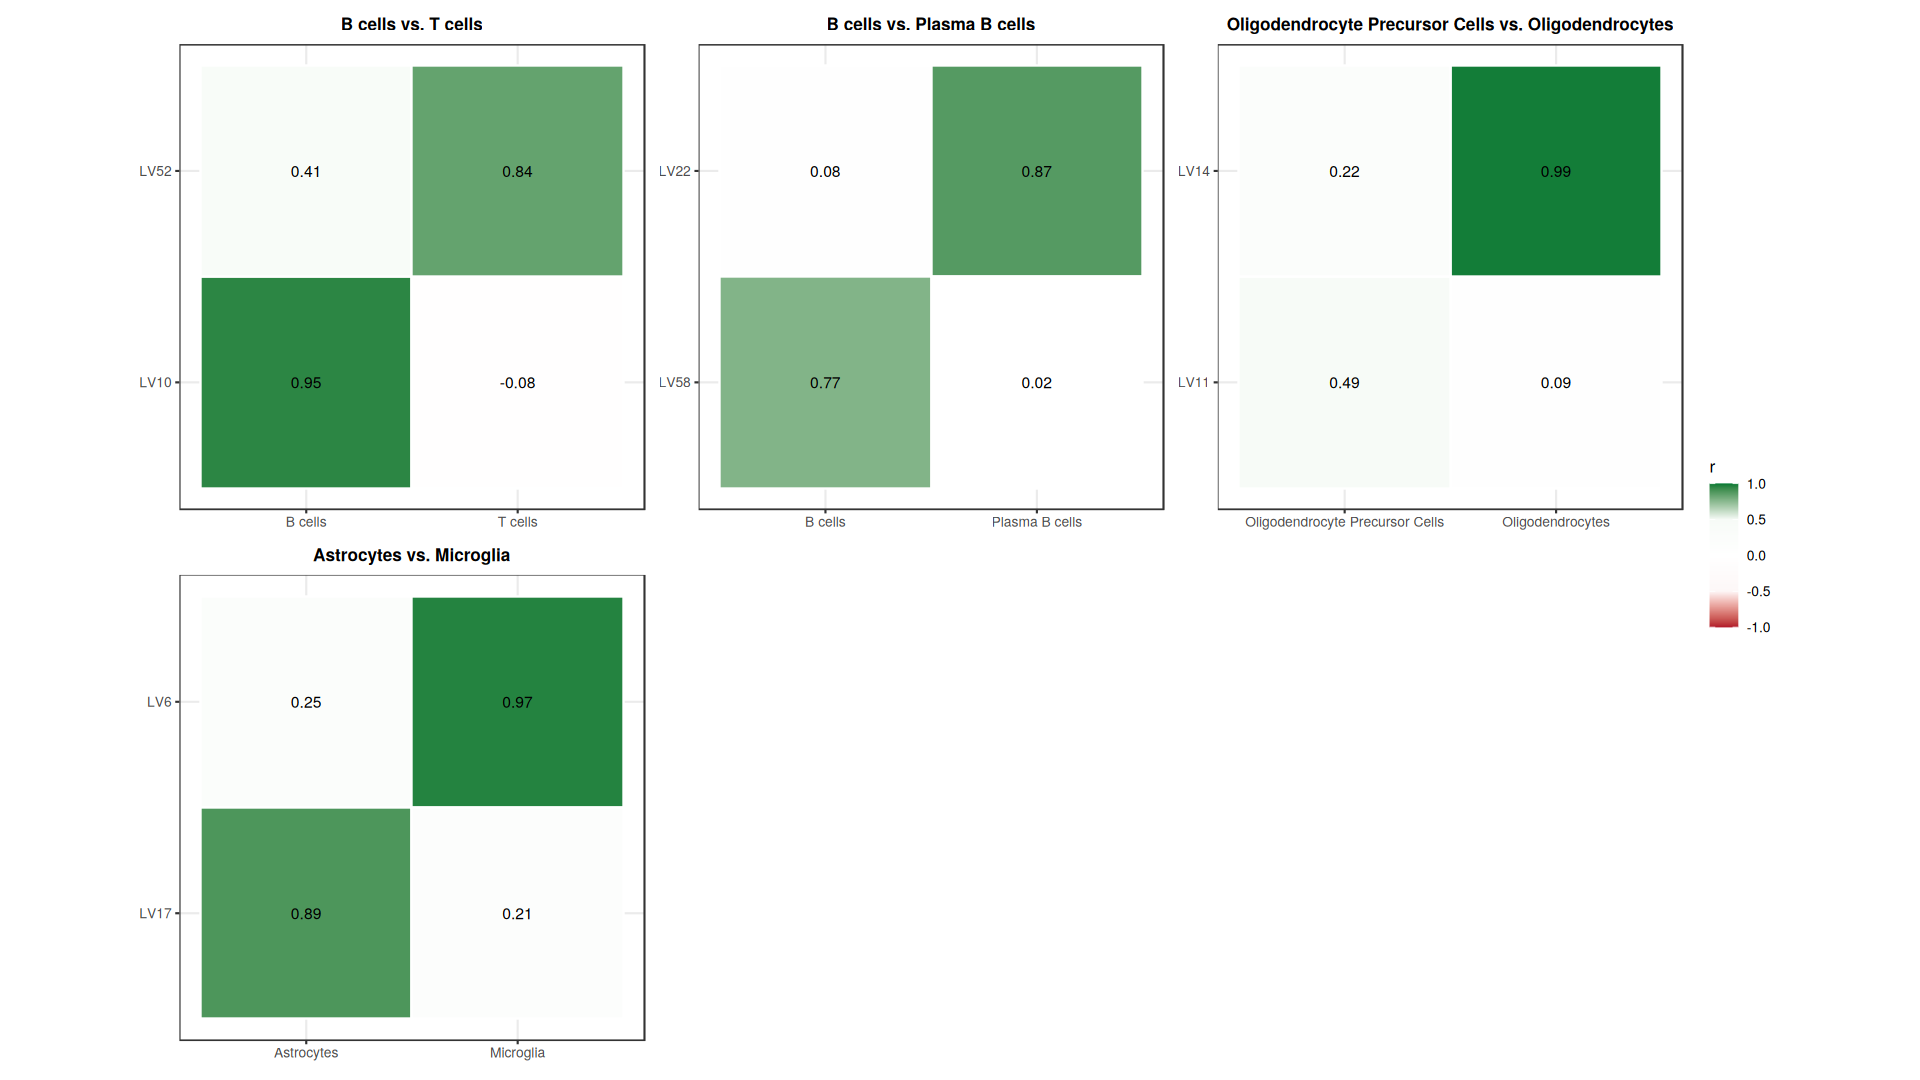

In [2]:
# Biologically related cell-type subtypes, checked per dataset
RELATED_GROUPS <- list(
    list(ds = "PBMC_Perez2022",  cts = c("B_cell", "T_cell")),
    list(ds = "PBMC_1k1k",        cts = c("B_cell", "Plasma_B")),
    list(ds = "Brain_Xiong2023",  cts = c("Opc", "Oli")),
    list(ds = "Brain_Mathys2023", cts = c("Ast", "Mic"))
)

group_panels <- lapply(RELATED_GROUPS, function(grp) {
    ds        <- grp$ds
    ds_assign <- top_lvs_df[top_lvs_df$dataset == ds, ]
    cts       <- intersect(grp$cts, ds_assign$cell_type)
    if (length(cts) < 2) return(NULL)

    lvs <- ds_assign$LV[match(cts, ds_assign$cell_type)]
    sub <- lv_corr_full[lv_corr_full$dataset == ds & lv_corr_full$LV %in% lvs &
                         lv_corr_full$cell_type %in% cts, ]
    sub$cell_type_label <- factor(ct_label(sub$cell_type), levels = ct_label(cts))
    sub$LV              <- factor(sub$LV, levels = lvs)

    ggplot(sub, aes(x = cell_type_label, y = LV, fill = cor)) +
        geom_tile(color = "white", linewidth = 0.5) +
        geom_text(aes(label = sprintf("%.2f", cor)), size = 3.2) +
        # Match the full correlation heatmaps: weak correlations stay near white.
        scale_fill_gradientn(colours = c("#b2182b", "#fdf7f7", "white", "#f7fbf7", "#007a33"),
                             values = scales::rescale(c(-1, -0.5, 0, 0.5, 1)),
                             limits = c(-1, 1), name = "r") +
        coord_fixed() +
        theme_bw(base_size = 10) +
        theme(plot.title = element_text(face = "bold", size = 10, hjust = 0.5)) +
        labs(x = NULL, y = NULL,
             title = paste(ct_label(cts), collapse = " vs. "))
})
group_panels <- Filter(Negate(is.null), group_panels)

options(repr.plot.width = 16, repr.plot.height = 9)
p_groups <- wrap_plots(group_panels, ncol = 3, guides = "collect") &
    theme(legend.position = "right")
print(p_groups)

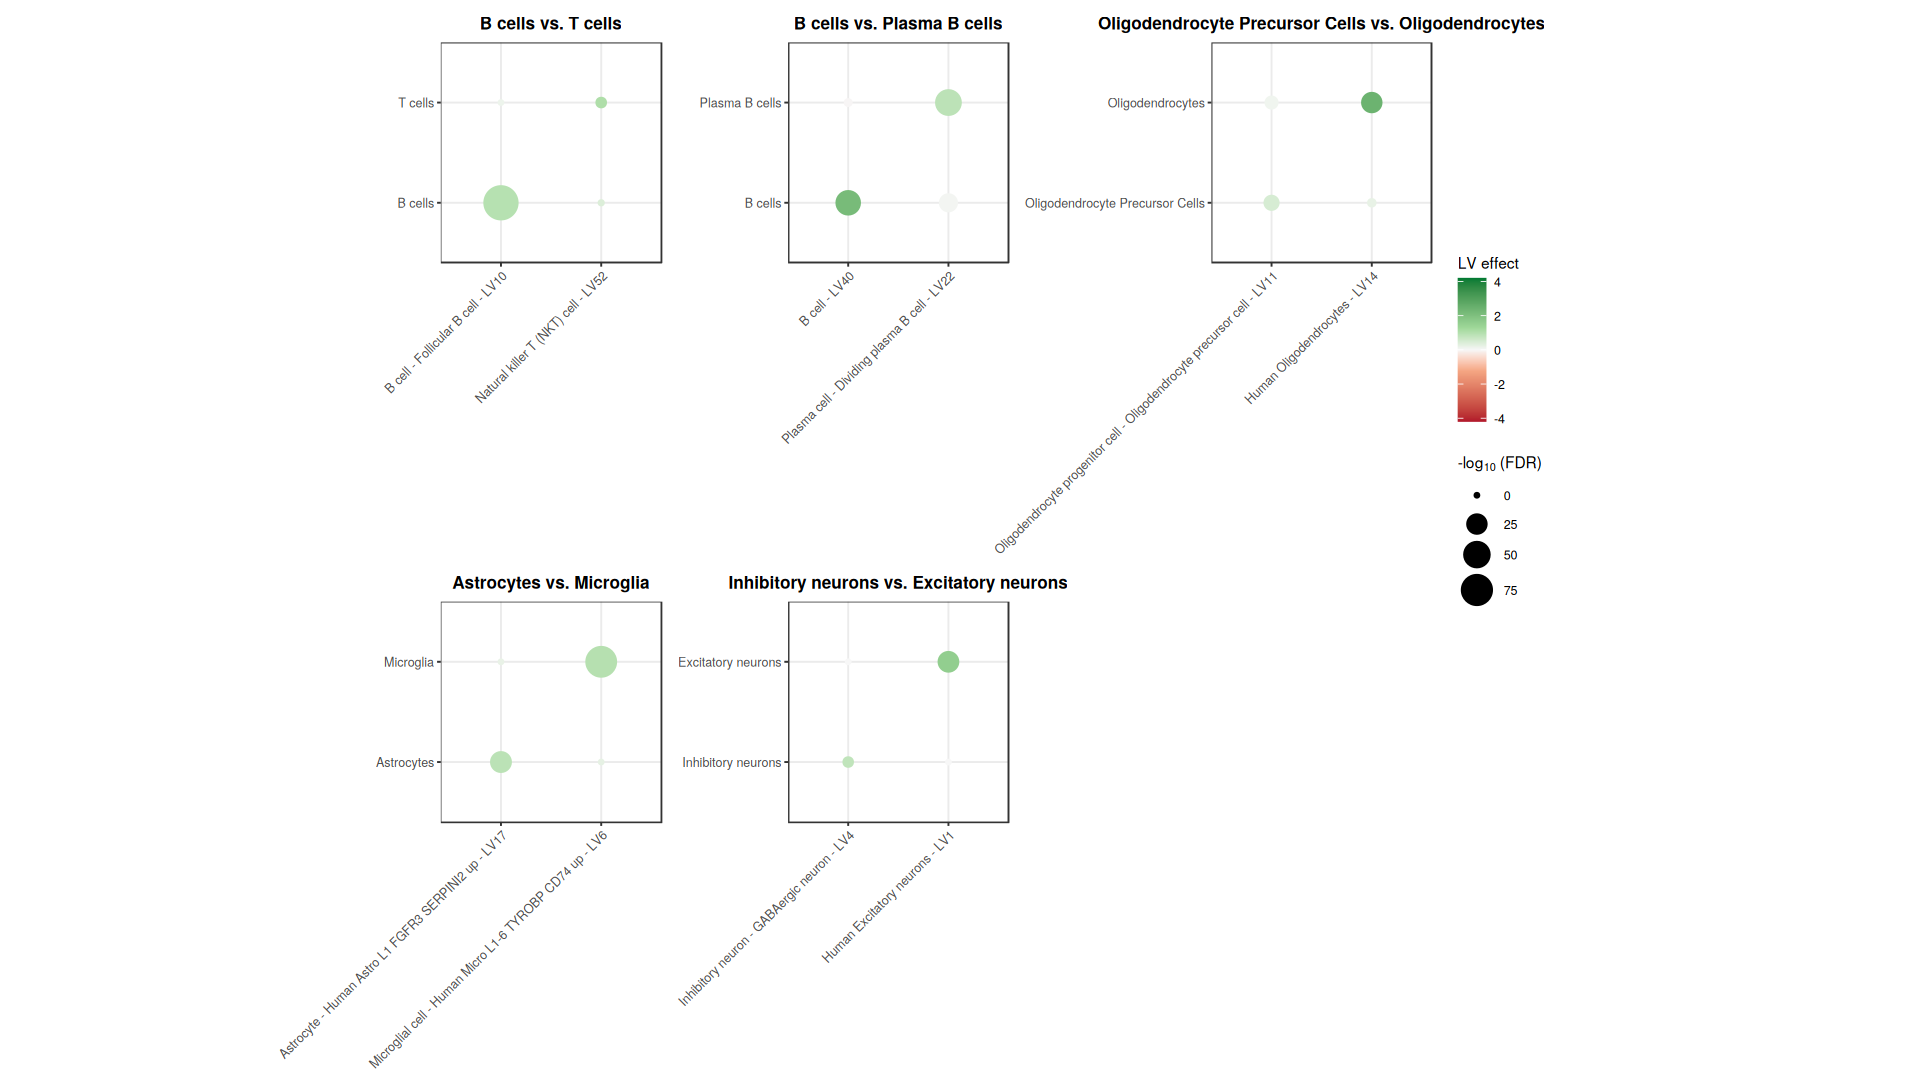

In [3]:
# Zoomed dot-grid (reuses enr_all/Z_LIM/Q_LIM from the main plot above,
# unmodified) restricted to the hardest cases: biologically related cell-type
# subtypes. Most panels compare cells within the same dataset; the final panel
# intentionally compares selected brain LVs across datasets. Cross-dataset cells
# are shown as neutral when they were not part of the dataset-local enrichment
# table.
RELATED_GROUPS <- list(
    list(entries = data.frame(ds = c("PBMC_Perez2022", "PBMC_Perez2022"),
                              ct = c("B_cell", "T_cell"), stringsAsFactors = FALSE)),
    list(entries = data.frame(ds = c("PBMC_1k1k", "PBMC_1k1k"),
                              ct = c("B_cell", "Plasma_B"), stringsAsFactors = FALSE)),
    list(entries = data.frame(ds = c("Brain_Xiong2023", "Brain_Xiong2023"),
                              ct = c("Opc", "Oli"), stringsAsFactors = FALSE)),
    list(entries = data.frame(ds = c("Brain_Mathys2023", "Brain_Mathys2023"),
                              ct = c("Ast", "Mic"), stringsAsFactors = FALSE)),
    list(entries = data.frame(ds = c("Brain_Mathys2023", "Brain_Xiong2023"),
                              ct = c("Inh", "Exc"), stringsAsFactors = FALSE))
)

make_group_dot_panel <- function(grp) {
    entries <- grp$entries
    entries$entry_id <- paste(entries$ds, entries$ct, sep = "__")

    sel <- dplyr::bind_rows(lapply(seq_len(nrow(entries)), function(i) {
        ds  <- entries$ds[i]
        ct  <- entries$ct[i]
        res <- module_results[[ds]]
        if (is.null(res)) return(NULL)
        row <- res$selected[res$selected$cell_type == ct, ]
        if (nrow(row) == 0) return(NULL)
        row <- row[1, , drop = FALSE]
        row$entry_dataset   <- ds
        row$entry_cell_type <- ct
        row$entry_id        <- entries$entry_id[i]
        row
    }))
    if (nrow(sel) < 2) return(NULL)

    row_labels <- setNames(ct_label(entries$ct), entries$entry_id)
    tp_for_sel <- dplyr::bind_rows(lapply(seq_len(nrow(sel)), function(i) {
        tp <- top_pathway_df[top_pathway_df$dataset == sel$entry_dataset[i] &
                             top_pathway_df$cell_type == sel$entry_cell_type[i], ]
        if (nrow(tp) == 0) return(data.frame(
            entry_id = sel$entry_id[i], top_pathway_label = NA_character_,
            recovered = FALSE, top1_fdr = NA_real_, stringsAsFactors = FALSE))
        data.frame(entry_id = sel$entry_id[i], top_pathway_label = tp$top_pathway_label[1],
                   recovered = tp$recovered[1], top1_fdr = tp$top1_fdr[1],
                   stringsAsFactors = FALSE)
    }))
    tp_label <- setNames(tp_for_sel$top_pathway_label, tp_for_sel$entry_id)
    col_labels <- setNames(
        ifelse(is.na(tp_label[sel$entry_id]) | tp_label[sel$entry_id] == sel$LV,
               sel$LV, paste0(tp_label[sel$entry_id], " - ", sel$LV)),
        sel$entry_id)
    recovered_by_entry <- setNames(tp_for_sel$recovered, tp_for_sel$entry_id)
    top1_neg_log10_by_entry <- setNames(-log10(tp_for_sel$top1_fdr + 1e-300),
                                        tp_for_sel$entry_id)

    enr <- dplyr::bind_rows(lapply(seq_len(nrow(sel)), function(i) {
        marker_cts <- entries$ct[entries$ds == sel$entry_dataset[i]]
        sub <- enr_all[enr_all$dataset == sel$entry_dataset[i] &
                       enr_all$LV == sel$LV[i] &
                       enr_all$lv_cell_type == sel$entry_cell_type[i] &
                       enr_all$marker_cell_type %in% marker_cts, ]
        if (nrow(sub) == 0) return(NULL)
        sub$lv_entry_id     <- sel$entry_id[i]
        sub$marker_entry_id <- paste(sub$dataset, sub$marker_cell_type, sep = "__")
        sub
    }))
    if (!all(c("marker_entry_id", "lv_entry_id") %in% names(enr))) {
        enr <- data.frame(marker_entry_id = character(), lv_entry_id = character(),
                          neg_log10_fdr = numeric(), row_effect = numeric(),
                          stringsAsFactors = FALSE)
    }

    grid <- expand.grid(marker_entry_id = entries$entry_id,
                        lv_entry_id = sel$entry_id,
                        stringsAsFactors = FALSE)
    enr <- merge(grid, enr, by = c("marker_entry_id", "lv_entry_id"), all.x = TRUE)
    enr$neg_log10_fdr[is.na(enr$neg_log10_fdr)] <- 0

    effect_lookup <- dplyr::bind_rows(lapply(seq_len(nrow(sel)), function(i) {
        marker_entries <- entries[entries$ds == sel$entry_dataset[i], ]
        eff <- lv_effect_all[lv_effect_all$dataset == sel$entry_dataset[i] &
                             lv_effect_all$LV == sel$LV[i] &
                             lv_effect_all$marker_cell_type %in% marker_entries$ct, ]
        if (nrow(eff) == 0) return(NULL)
        eff$lv_entry_id     <- sel$entry_id[i]
        eff$marker_entry_id <- paste(eff$dataset, eff$marker_cell_type, sep = "__")
        eff[, c("marker_entry_id", "lv_entry_id", "row_effect")]
    }))
    enr$row_effect <- NULL
    if (nrow(effect_lookup) > 0)
        enr <- merge(enr, effect_lookup, by = c("marker_entry_id", "lv_entry_id"), all.x = TRUE)
    if (!"row_effect" %in% names(enr)) enr$row_effect <- NA_real_
    enr$row_effect[is.na(enr$row_effect)] <- 0

    recover_idx <- enr$marker_entry_id == enr$lv_entry_id &
                   recovered_by_entry[enr$lv_entry_id] %in% TRUE &
                   !is.na(top1_neg_log10_by_entry[enr$lv_entry_id])
    enr$neg_log10_fdr[recover_idx] <- pmax(enr$neg_log10_fdr[recover_idx],
                                           top1_neg_log10_by_entry[enr$lv_entry_id[recover_idx]])
    enr$marker_row_label <- factor(row_labels[enr$marker_entry_id], levels = unname(row_labels))
    enr$lv_col_label     <- factor(col_labels[enr$lv_entry_id], levels = unname(col_labels))

    ggplot(enr, aes(x = lv_col_label, y = marker_row_label)) +
        geom_point(aes(size = neg_log10_fdr, color = row_effect)) +
        scale_size_continuous(limits = c(0, Q_LIM), range = c(1, 9),
                              name = expression("-" * log[10] ~ "(FDR)")) +
        scale_color_gradientn(colors = c("#b2182b", "#f4a582", "#f7f7f7", "#a1d99b", "#007a33"),
                              values = c(0, 0.35, 0.5, 0.65, 1),
                              limits = c(-Z_LIM, Z_LIM),
                              name = "LV effect") +
        coord_fixed() +
        theme_bw(base_size = 9) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1),
              plot.title  = element_text(face = "bold", size = 10, hjust = 0.5)) +
        labs(x = NULL, y = NULL, title = paste(unname(row_labels), collapse = " vs. "))
}

group_dot_panels <- Filter(Negate(is.null), lapply(RELATED_GROUPS, make_group_dot_panel))

options(repr.plot.width = 16, repr.plot.height = 9)
p_group_dots <- wrap_plots(group_dot_panels, ncol = 3, guides = "collect") &
    theme(legend.position = "right")
print(p_group_dots)


## Export canonical hard-cell results

In [4]:
hard_entries <- dplyr::bind_rows(lapply(seq_along(RELATED_GROUPS), function(i) {
  entries <- RELATED_GROUPS[[i]]$entries
  entries$group_id <- i
  entries
}))

hard_table <- hard_entries %>%
  left_join(top_lvs_df, by = c('ds' = 'dataset', 'ct' = 'cell_type')) %>%
  left_join(recovery_df, by = c('ds' = 'dataset', 'ct' = 'cell_type'),
            suffix = c('_specificity', '_singlecell'))

hard_corr_long <- dplyr::bind_rows(lapply(seq_len(nrow(hard_entries)), function(i) {
  entry <- hard_entries[i, ]
  assigned <- top_lvs_df[top_lvs_df$dataset == entry$ds & top_lvs_df$cell_type == entry$ct, ]
  if (!nrow(assigned)) return(NULL)
  candidates <- hard_entries$ct[hard_entries$ds == entry$ds]
  out <- lv_corr_full[lv_corr_full$dataset == entry$ds &
                      lv_corr_full$LV == assigned$LV[1] &
                      lv_corr_full$cell_type %in% candidates, ]
  if (!nrow(out)) return(NULL)
  out$assigned_cell_type <- entry$ct
  out$group_id <- entry$group_id
  out
}))

hard_enrichment_long <- dplyr::bind_rows(lapply(seq_len(nrow(hard_entries)), function(i) {
  entry <- hard_entries[i, ]
  assigned <- top_lvs_df[top_lvs_df$dataset == entry$ds & top_lvs_df$cell_type == entry$ct, ]
  if (!nrow(assigned)) return(NULL)
  candidates <- hard_entries$ct[hard_entries$ds == entry$ds]
  out <- enr_all[enr_all$dataset == entry$ds & enr_all$LV %in% assigned$LV &
                 enr_all$marker_cell_type %in% candidates, ]
  if (!nrow(out)) return(NULL)
  out$group_id <- entry$group_id
  out
}))

write.csv(hard_table, file.path(OUT_DIR, 'hard_cell_types.csv'), row.names = FALSE)
write.csv(hard_corr_long, file.path(OUT_DIR, 'related_lv_correlations.csv'), row.names = FALSE)
write.csv(hard_enrichment_long, file.path(OUT_DIR, 'hard_marker_enrichment.csv'), row.names = FALSE)
ggsave(file.path(OUT_DIR, 'related_lv_correlation_heatmaps.png'), p_groups,
       width = 16, height = 9, dpi = 150)
ggsave(file.path(OUT_DIR, 'hard_cell_marker_enrichment.png'), p_group_dots,
       width = 16, height = 9, dpi = 150)
hard_table

ds,ct,group_id,LV,cor,r_next_best_ct,r_next_best_lv,margin_ct,margin_lv,n_top,⋯,diag_count,recovery_pct,assigned_lv,assignment_cor,n_true_cells,n_population,prevalence,max_achievable_purity,purity_ratio,purity_lift
<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<dbl>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
PBMC_Perez2022,B_cell,1,LV10,0.9541733,0.4066530,-0.04478081,0.54752027,0.9989541,12637,⋯,12636,99.99209,LV10,0.9541733,152981,1263676,0.121060303,1.0000000,0.9999209,8.259692
PBMC_Perez2022,T_cell,1,LV52,0.8393497,0.7826709,0.40665303,0.05667882,0.4326967,12637,⋯,9663,76.46593,LV52,0.8393497,637669,1263676,0.504614316,1.0000000,0.7646593,1.515334
PBMC_1k1k,B_cell,2,LV58,0.7724319,0.7368362,0.08288588,0.03559563,0.6895460,12490,⋯,10858,95.46334,LV58,0.7724319,125825,1231937,0.102135905,1.0000000,0.9546334,9.346697
PBMC_1k1k,Plasma_B,2,LV22,0.8732784,0.3180721,0.12990837,0.55520628,0.7433700,12490,⋯,3754,35.23559,LV22,0.8732784,3754,1231937,0.003047234,0.3523559,1.0000000,115.631406
Brain_Xiong2023,Opc,3,LV11,0.4875953,0.4749612,0.08820277,0.01263412,0.3993926,4150,⋯,1389,33.59942,LV11,0.4875953,19272,414964,0.046442583,1.0000000,0.3359942,7.234615
Brain_Xiong2023,Oli,3,LV14,0.9865262,0.7738526,0.57928853,0.21267353,0.4072376,4150,⋯,4150,100.00000,LV14,0.9865262,119456,414964,0.287870755,1.0000000,1.0000000,3.473781
Brain_Mathys2023,Ast,4,LV17,0.8911263,0.3225390,0.48450306,0.56858730,0.4066232,4000,⋯,3978,100.00000,LV17,0.8911263,25607,400000,0.064017500,1.0000000,1.0000000,15.620729
Brain_Mathys2023,Mic,4,LV6,0.9655128,0.4927088,0.25219939,0.47280405,0.7133134,4000,⋯,4000,100.00000,LV6,0.9655128,13247,400000,0.033117500,1.0000000,1.0000000,30.195516
Brain_Mathys2023,Inh,5,LV4,0.8155799,0.6555200,0.43420649,0.16005985,0.3813734,4000,⋯,3458,86.45000,LV4,0.8155799,56468,400000,0.141170000,1.0000000,0.8645000,6.123822
